# Task 4: Banknote Authentication Classification

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [2]:
df = pd.read_csv("data_banknote_authentication.csv")
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df.shape

(1372, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


## Data Preprocessing

### Check for Missing Values

In [6]:
df.isnull().sum()

Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64

### Check for Duplicate Rows

In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 24
Shape after removing duplicates: (1348, 5)


### Check for Outliers

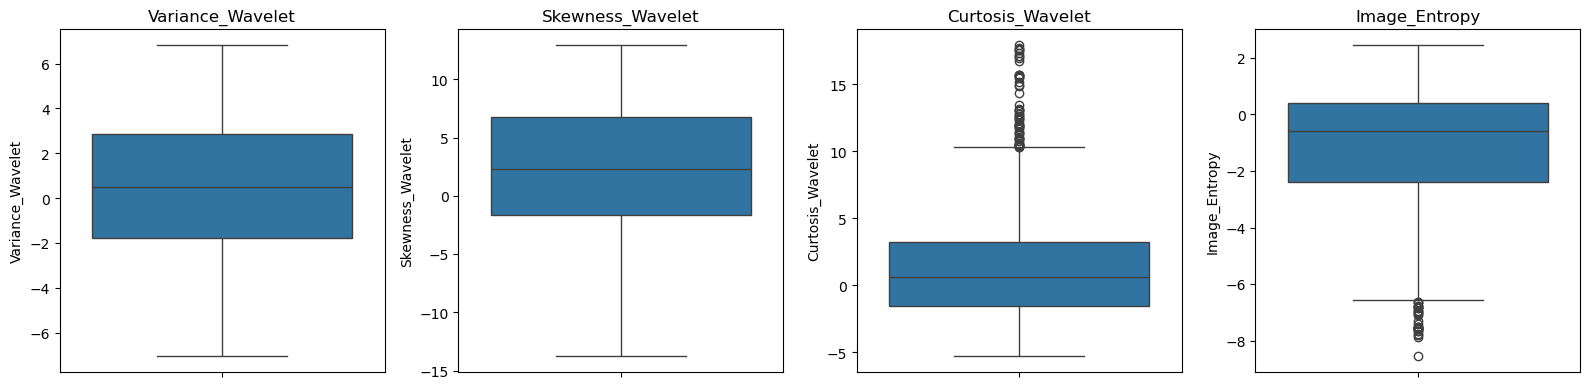

In [9]:
# Visualize outliers using boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [10]:
# Handle outliers using IQR capping (clip instead of removing)
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outliers_count} outliers detected")
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print(f"\nShape after handling outliers: {df.shape}")

Variance_Wavelet: 0 outliers detected
Skewness_Wavelet: 0 outliers detected
Curtosis_Wavelet: 59 outliers detected
Image_Entropy: 32 outliers detected

Shape after handling outliers: (1348, 5)


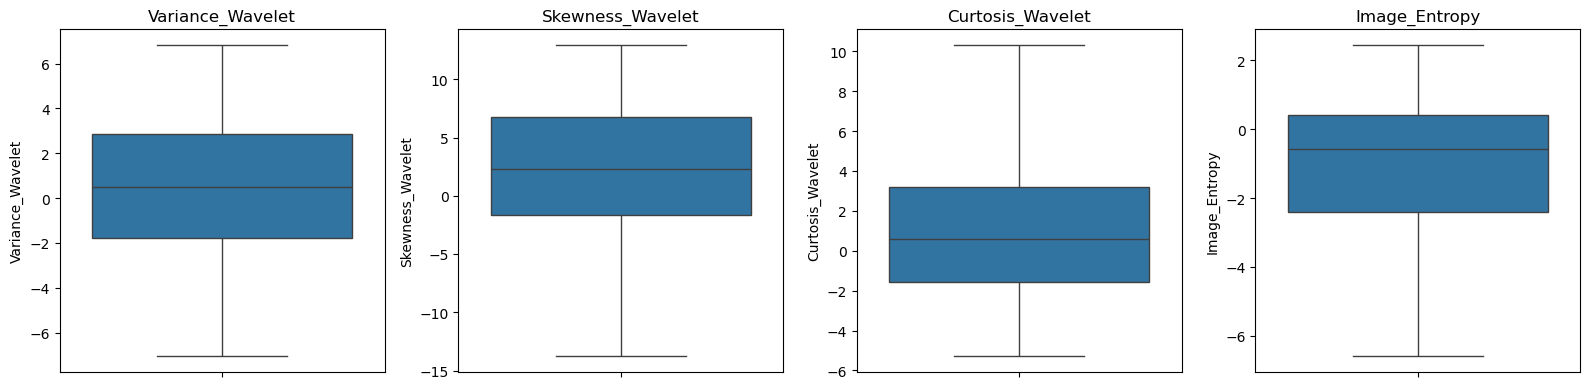

In [11]:
# Boxplots after handling outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Train | Test Split

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Decision Tree Classifier

## Default Model

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

Decision Tree - Default Hyperparameters
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       233
           1       0.99      0.98      0.99       172

    accuracy                           0.99       405
   macro avg       0.99      0.99      0.99       405
weighted avg       0.99      0.99      0.99       405



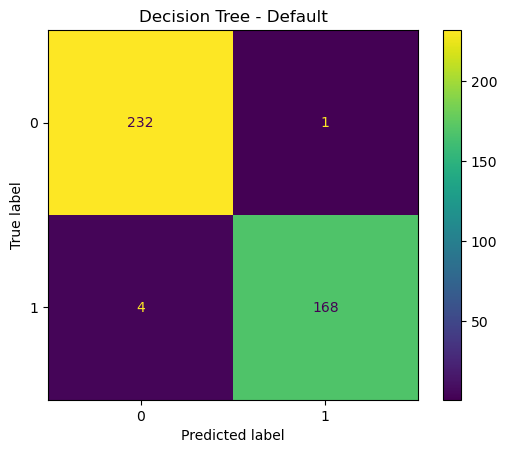

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Decision Tree - Default Hyperparameters")
print(classification_report(y_test, dt_preds))

ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)
plt.title("Decision Tree - Default")
plt.show()

## Visualize the Decision Tree

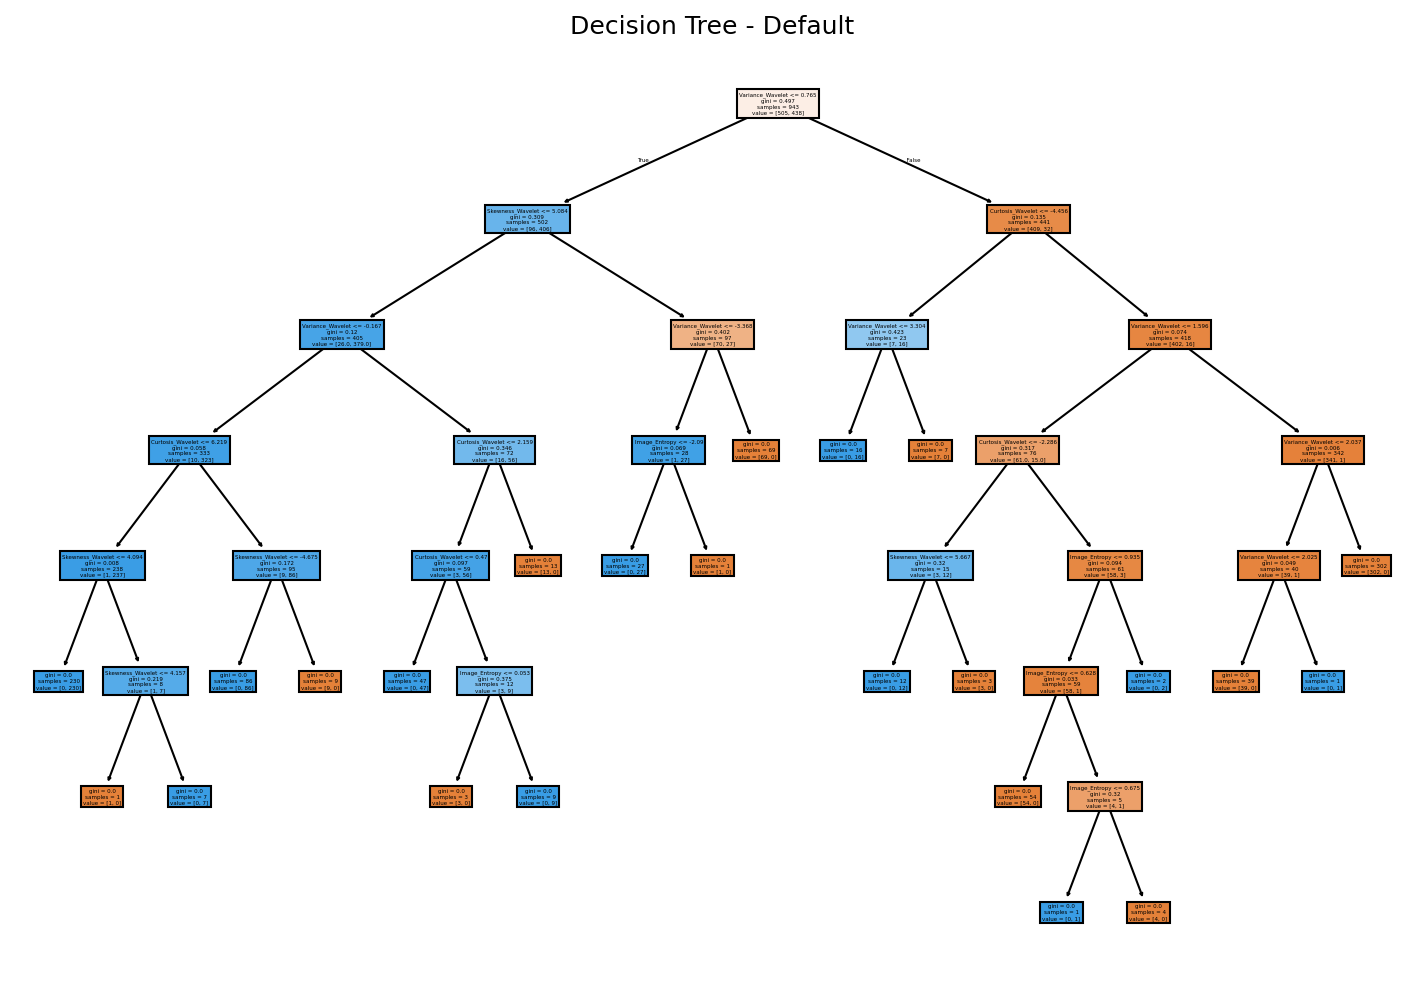

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8), dpi=150)
plot_tree(dt_model, filled=True, feature_names=X.columns)
plt.title("Decision Tree - Default")
plt.show()

## GridSearchCV - Decision Tree

In [17]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
    'max_leaf_nodes': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV Accuracy: {dt_grid.best_score_:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 8, 'max_leaf_nodes': 15, 'min_samples_split': 10}
Best CV Accuracy: 0.9788


## Evaluate Best Decision Tree

Decision Tree - Best Model (GridSearchCV)
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       233
           1       0.98      0.99      0.99       172

    accuracy                           0.99       405
   macro avg       0.99      0.99      0.99       405
weighted avg       0.99      0.99      0.99       405



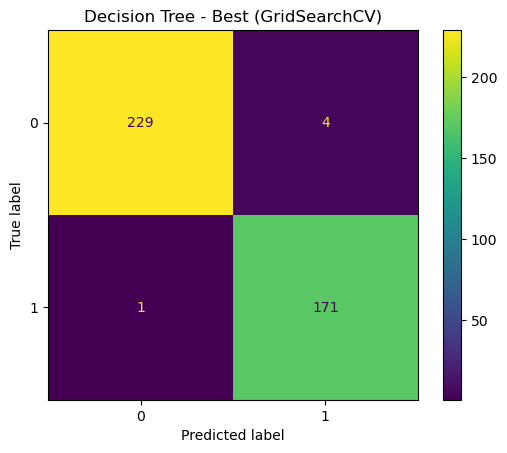

In [18]:
best_dt = dt_grid.best_estimator_
best_dt_preds = best_dt.predict(X_test)

print("Decision Tree - Best Model (GridSearchCV)")
print(classification_report(y_test, best_dt_preds))

ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test)
plt.title("Decision Tree - Best (GridSearchCV)")
plt.show()

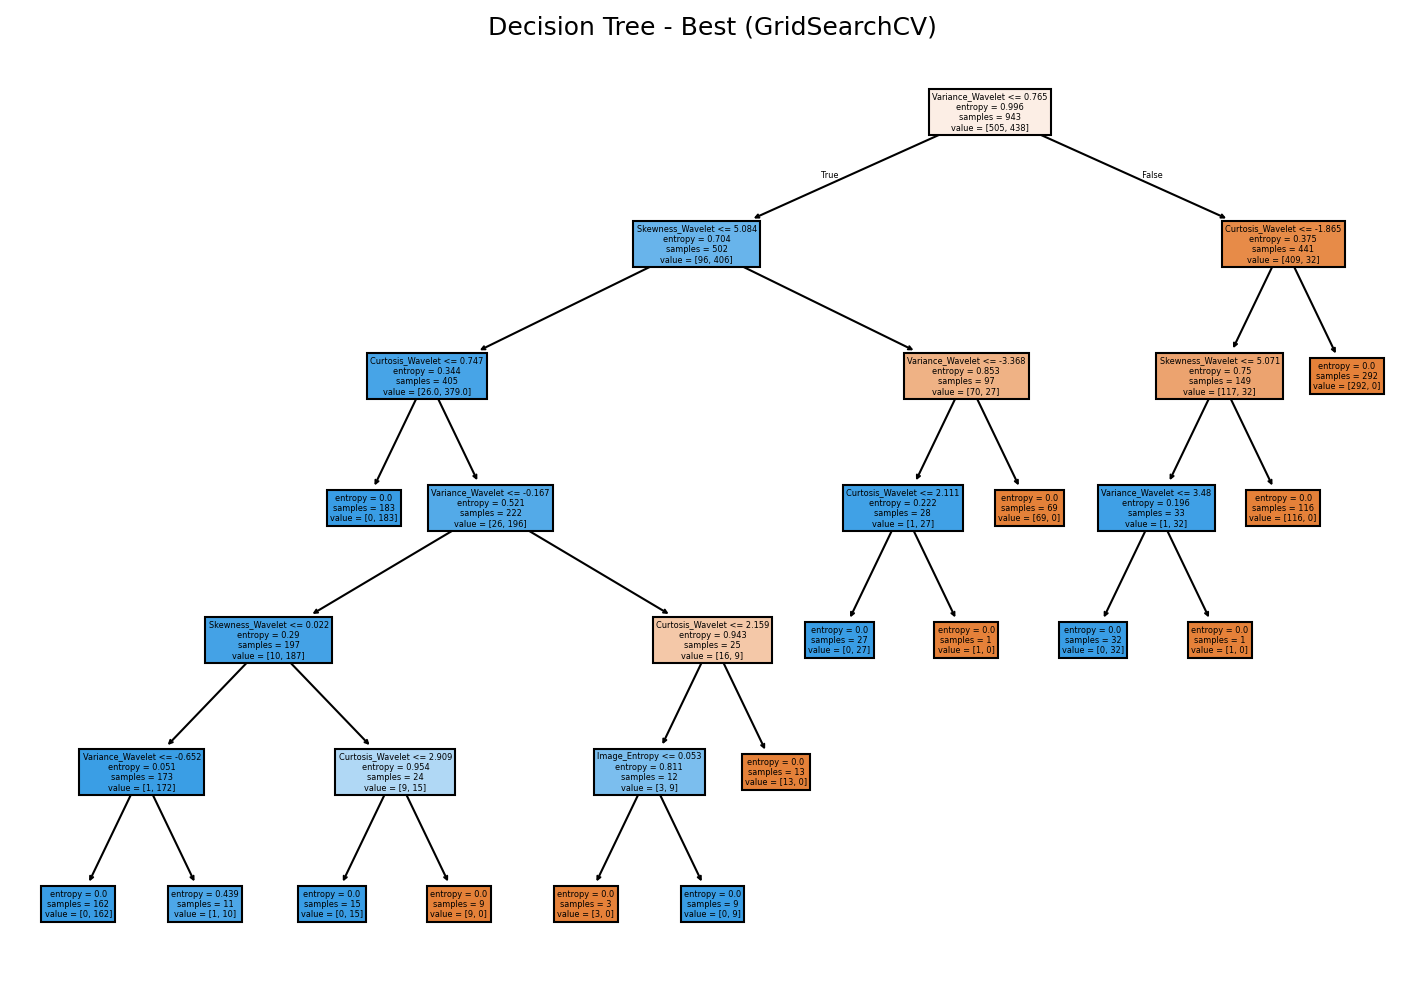

In [19]:
plt.figure(figsize=(12, 8), dpi=150)
plot_tree(best_dt, filled=True, feature_names=X.columns)
plt.title("Decision Tree - Best (GridSearchCV)")
plt.show()

# Random Forest Classifier

## Default Model

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

Random Forest - Default Hyperparameters
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       233
           1       0.99      0.99      0.99       172

    accuracy                           1.00       405
   macro avg       0.99      0.99      0.99       405
weighted avg       1.00      1.00      1.00       405



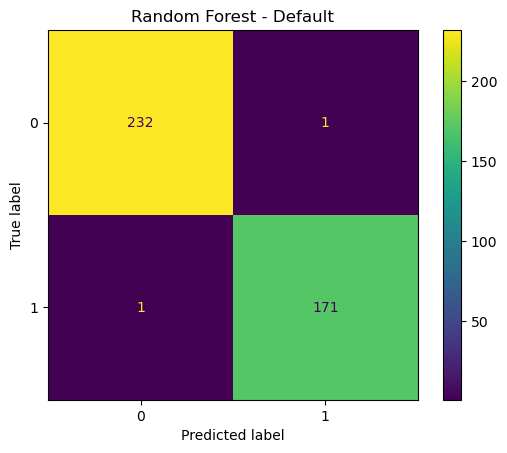

In [21]:
print("Random Forest - Default Hyperparameters")
print(classification_report(y_test, rf_preds))

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest - Default")
plt.show()

## GridSearchCV - Random Forest

In [22]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

Best Parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.9915


## Evaluate Best Random Forest

Random Forest - Best Model (GridSearchCV)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       233
           1       0.99      0.99      0.99       172

    accuracy                           1.00       405
   macro avg       0.99      0.99      0.99       405
weighted avg       1.00      1.00      1.00       405



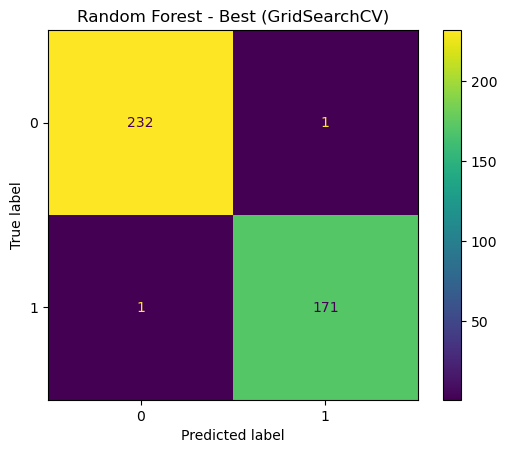

In [23]:
best_rf = rf_grid.best_estimator_
best_rf_preds = best_rf.predict(X_test)

print("Random Forest - Best Model (GridSearchCV)")
print(classification_report(y_test, best_rf_preds))

ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Random Forest - Best (GridSearchCV)")
plt.show()

# Model Comparison

In [24]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': ['Decision Tree (Default)', 'Decision Tree (GridSearch)',
              'Random Forest (Default)', 'Random Forest (GridSearch)'],
    'Accuracy': [
        accuracy_score(y_test, dt_preds),
        accuracy_score(y_test, best_dt_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, best_rf_preds)
    ]
})

results = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results

,Model,Accuracy
0,Random Forest (GridSearch),0.995062
1,Random Forest (Default),0.995062
2,Decision Tree (GridSearch),0.987654
3,Decision Tree (Default),0.987654


C:\Users\kwael\AppData\Local\Temp\ipykernel_27916\3462925728.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Accuracy', y='Model', palette='viridis')


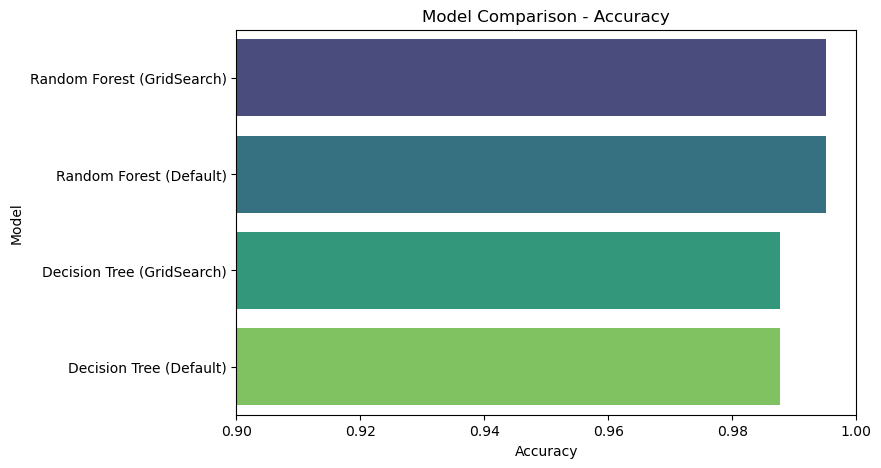

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Comparison - Accuracy')
plt.xlim(0.9, 1.0)
plt.show()

## Conclusion

**Random Forest** is expected to perform better than a single **Decision Tree** because:

1. **Ensemble approach**: Random Forest combines predictions from multiple trees, reducing variance and overfitting.
2. **Bootstrap aggregation**: Each tree sees a different subset of data, making the model more robust.
3. **Feature randomness**: Randomly selecting features at each split reduces correlation between trees.

**GridSearchCV** helps both models by finding optimal hyperparameters through cross-validation, ensuring the best configuration is selected rather than relying on defaults.

The comparison table and bar chart above show the accuracy of each model variant, confirming which approach works best for the banknote authentication dataset.